# Benchmarking Forecasting Methods\n\nThis notebook compares how different forecasting methods affect the bullwhip effect\nunder a fixed Order-Up-To policy.\n\nWe compare:\n- **Naive**: Sample mean/std of full history\n- **MA(10)**: 10-period moving average\n- **MA(52)**: 52-period (1-year) moving average\n- **SES(0.3)**: Single exponential smoothing (alpha=0.3)

In [1]:
# --- Colab / Environment Setup ---
# Run this cell first if using Google Colab or a fresh environment.
import importlib, sys

if "google.colab" in sys.modules:
    print("Running on Google Colab -- installing deepbullwhip...")
    get_ipython().system('pip install -q deepbullwhip')
elif importlib.util.find_spec("deepbullwhip") is None:
    print("deepbullwhip not found -- installing from local source...")
    get_ipython().system('pip install -q -e ..')
else:
    print(f"deepbullwhip ready (v{__import__('deepbullwhip').__version__})")

deepbullwhip ready (v0.3.0)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from deepbullwhip.benchmark import BenchmarkRunner
from deepbullwhip.diagnostics.plots import COLORS, _apply_style, DOUBLE_COL, SINGLE_COL, GOLDEN

_apply_style()

runner = BenchmarkRunner(
    chain_config="semiconductor_4tier",
    demand="semiconductor_ar1",
    T=156,
    N=50,
    seed=42,
)

results = runner.run(
    policies=["order_up_to"],
    forecasters=[
        "naive",
        ("moving_average", {"window": 10}),
        ("moving_average", {"window": 52}),
        ("exponential_smoothing", {"alpha": 0.3}),
    ],
    metrics=["BWR", "FILL_RATE", "TC"],
)

pivot = results.pivot_table(
    index=["forecaster", "echelon"],
    columns="metric",
    values="value",
    aggfunc="mean",
)
print(pivot.to_string(float_format="%.3f"))

metric                            BWR  FILL_RATE       TC
forecaster            echelon                            
exponential_smoothing E1        1.583      0.824  135.936
                      E2        3.082      0.681  345.489
                      E3       25.254      0.652 1308.994
                      E4      442.930      0.824 1883.176
moving_average        E1        1.517      0.728  228.229
                      E2        2.804      0.677  327.491
                      E3       23.042      0.638 1292.804
                      E4      437.944      0.814 1841.194
naive                 E1        1.360      0.714  293.890
                      E2        2.386      0.676  296.637
                      E3       19.803      0.627 1224.242
                      E4      427.531      0.799 1727.949


## BWR by Forecasting Method (Echelon 1)\n\nChen et al. (2000) showed that the MA window size directly affects the bullwhip lower bound.

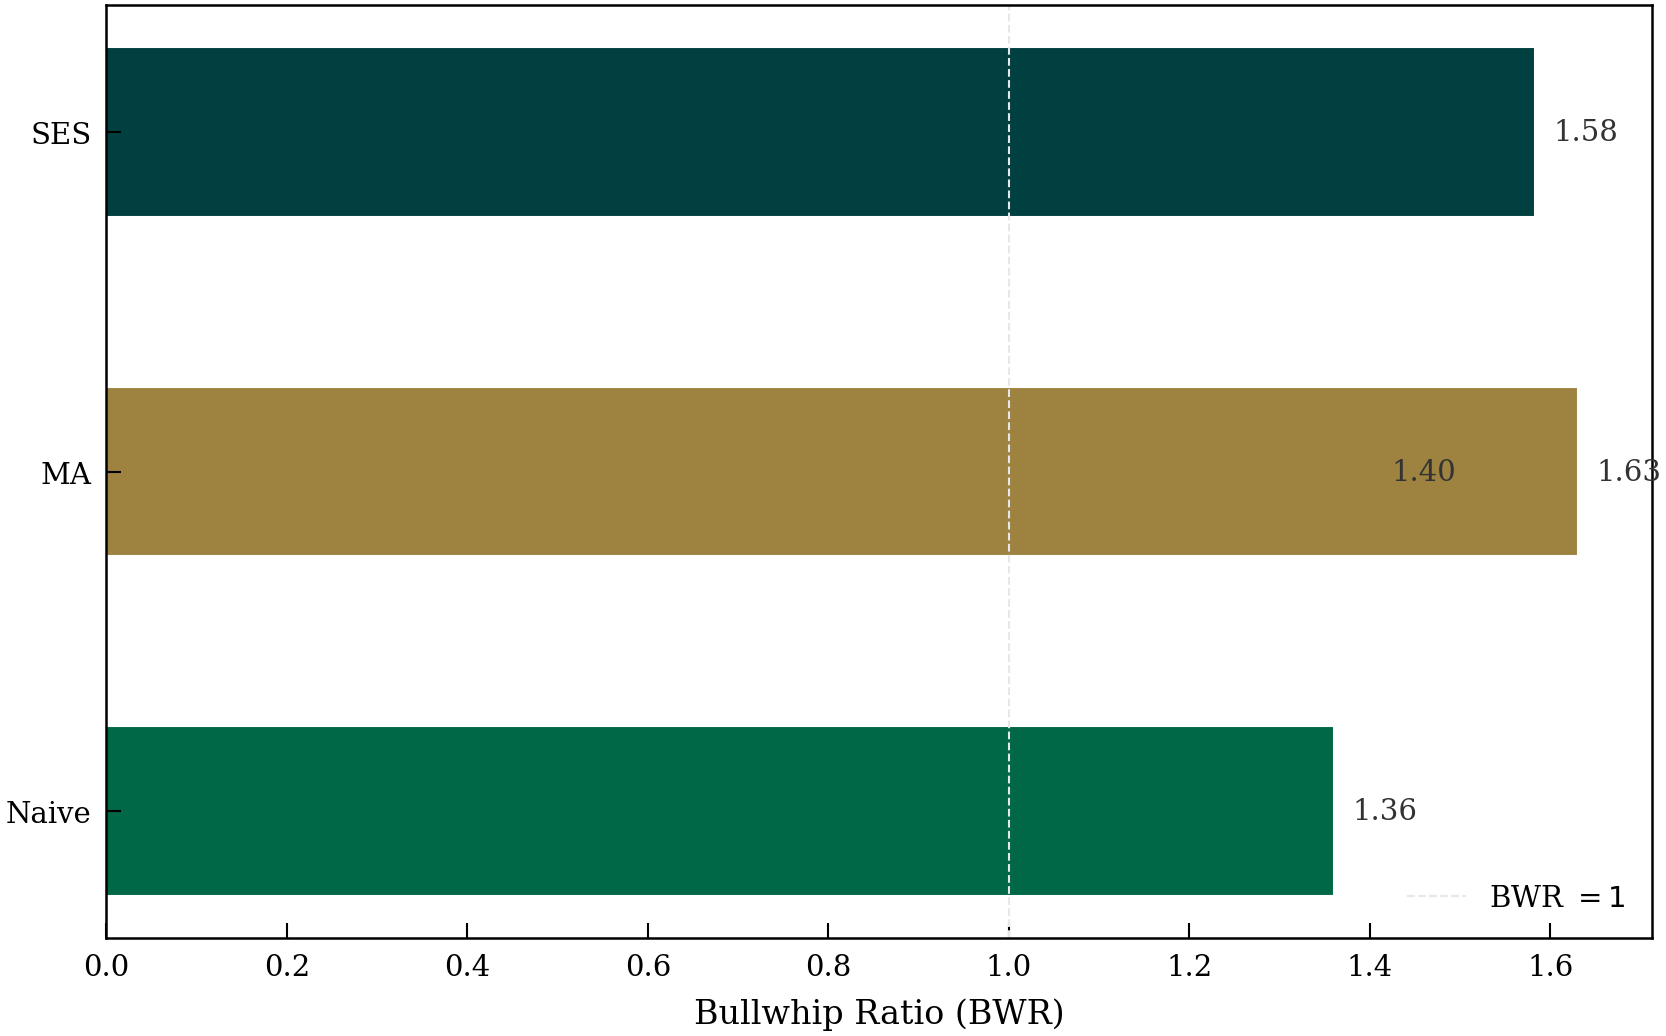

In [3]:
FC_COLORS = [COLORS["E1"], COLORS["E2"], COLORS["E3"], COLORS["E4"]]
FC_LABELS = {"naive": "Naive", "moving_average": "MA", "exponential_smoothing": "SES"}

e1_bwr = results[(results["echelon"] == "E1") & (results["metric"] == "BWR")].copy()
e1_bwr = e1_bwr.sort_values("value", ascending=True)

fig, ax = plt.subplots(figsize=(SINGLE_COL * 1.6, SINGLE_COL))

labels = [FC_LABELS.get(f, f) for f in e1_bwr["forecaster"]]
colors = [FC_COLORS[i % len(FC_COLORS)] for i in range(len(e1_bwr))]
bars = ax.barh(labels, e1_bwr["value"], color=colors, edgecolor="white",
               linewidth=0.5, height=0.5)

ax.axvline(x=1.0, color=COLORS["grid"], linestyle="--", linewidth=0.5,
           label=r"BWR $= 1$")
ax.set_xlabel("Bullwhip Ratio (BWR)")

for bar, val in zip(bars, e1_bwr["value"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=7, color="#333333")

ax.legend(loc="lower right", frameon=False)

fig.savefig("benchmark_forecasters_bwr.pdf", dpi=300, bbox_inches="tight")
fig.savefig("benchmark_forecasters_bwr.png", dpi=300, bbox_inches="tight")
plt.show()

## Chen Lower Bound Comparison

In [4]:
from deepbullwhip.metrics.bounds import ChenLowerBound

bound = ChenLowerBound(lead_time=2, sensitivity=1.0, phi=0.72)
print(f"Chen et al. (2000) lower bound: BWR >= {bound.compute_bound():.3f}")
print(f"Observed BWR (Naive, E1): {e1_bwr[e1_bwr['forecaster']=='naive']['value'].values[0]:.3f}")

Chen et al. (2000) lower bound: BWR >= 6.897
Observed BWR (Naive, E1): 1.360
